# Bert

In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import  DistilBertForSequenceClassification, DistilBertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
import os
from sklearn.model_selection import train_test_split


c:\Text Mining\Text_Mining\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
ONLY IF YOU USE COLAB:
from google.colab import drive
drive.mount('/content/drive')
"""
checkpoint_dir = "Bert_weights/bert_checkpoints" # "/content/drive/MyDrive/Bert_weights/bert_checkpoints"
os.makedirs(checkpoint_dir, exist_ok = True)


In [3]:


file_path = "financial_news_base.jsonl" # "/content/drive/MyDrive/Ds/financial_news_base.jsonl" for colab

df = pd.read_json(file_path, lines=True)


In [4]:
target_per_class = 25000 // 3

dfs = []
for label in df['sentiment_label'].unique():
    subset = df[df['sentiment_label'] == label]
    dfs.append(subset.sample(n=target_per_class, random_state=100))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=100).reset_index(drop=True)

print(df_balanced['sentiment_label'].value_counts())

sentiment_label
negative    8333
positive    8333
neutral     8333
Name: count, dtype: int64


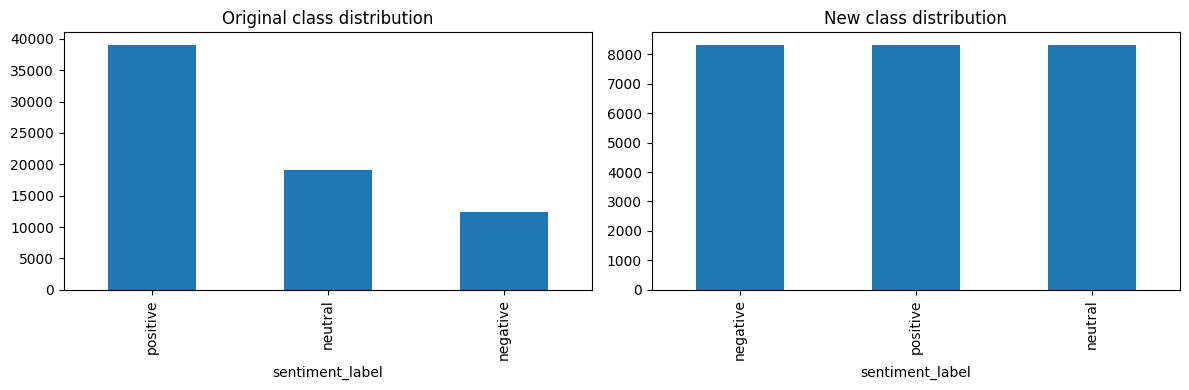

In [5]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[0], title='Original class distribution')
df_balanced['sentiment_label'].value_counts().plot(kind='bar', ax=axes[1], title='New class distribution')

plt.tight_layout()
plt.show()

In [6]:
df_bert = df_balanced[["description","sentiment_label"]]



In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
X = df_bert["description"]
y = df_bert["sentiment_label"].map({"positive": 0, "negative": 1, "neutral": 2}).astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=100)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=100)

print(X_train.shape, X_val.shape, X_test.shape)
y_train.head()

(17499,) (3750,) (3750,)


15970    1
14574    1
21395    0
2037     2
19629    1
Name: sentiment_label, dtype: int64

In [9]:
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

batch_texts = X_train.tolist()
train_tokenized = tokenizer(batch_texts,
                      padding="max_length",
                      truncation=True,
                      return_tensors="pt")

val_tokenized = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

test_tokenized = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)



In [10]:
y_train_tensor = torch.tensor(y_train.values)
y_val_tensor = torch.tensor(y_val.values)
y_test_tensor = torch.tensor(y_test.values)

In [11]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self,tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
      item = {key: val[idx] for key, val in self.tokens.items()}
      item["labels"] = self.labels[idx]
      return item

  def __len__(self):
      return len(self.labels)

In [12]:
#train_dataset = Dataset(train_tokenized, y_train_tensor)
#val_dataset = Dataset(val_tokenized, y_val_tensor)
#test_dataset = Dataset(test_tokenized, y_test_tensor)


#train_loader = DataLoader(train_dataset, batch_size = 16)
#val_loader = DataLoader(val_dataset, batch_size = 16)
#test_loader = DataLoader(test_dataset, batch_size = 16)

In [13]:
import time
from tqdm import tqdm


def train_epoch(model ,dataloader, optimizer, scheduler, device):
  model.train()
  total_loss = 0

  for batch in tqdm(dataloader, desc = "Training"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()

        # Forward pass: compute model predictions and loss
        # BertForSequenceClassification automatically computes loss when labels are provided
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss

        # Backward pass: compute gradients
    loss.backward()

        # Update weights based on gradients
    optimizer.step()

    scheduler.step()

    total_loss += loss.item()

  return total_loss / len(dataloader)

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
    return total_loss / len(dataloader)

# NEXT CELL: TRAIN FOR GPU

In [14]:
batch_size = 32
lr = 5e-6
warmup_ratio = 0.1

best_val_loss = float('inf')
train_losses = []
val_losses = []
train_loader = DataLoader(Dataset(train_tokenized, y_train_tensor), batch_size=batch_size)
val_loader = DataLoader(Dataset(val_tokenized, y_val_tensor), batch_size=batch_size)

config_finetune = DistilBertConfig.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    output_attentions=True,
    dropout=0.3,
    attention_dropout=0.15
)
model_finetune = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config_finetune)

model_finetune.to(device)

optimizer = AdamW(model_finetune.parameters(), lr=lr, weight_decay=0.05)
epochs = 5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(warmup_ratio * total_steps),
    num_training_steps=total_steps)


patience = 2   # consecutive epochs with no improvement (greater than min_delta) in validation loss.
min_delta = 0.01
patience_counter = 0
best_val_loss = float('inf')
best_epoch = -1
best_ckpt_path = os.path.join(checkpoint_dir, "bert_best_model.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(model_finetune, train_loader, optimizer, scheduler, device)
    val_loss = eval_epoch(model_finetune, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1} — Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")

    # Check if improved by at least min_delta
    improved = val_loss < best_val_loss * (1 - min_delta)

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        # Save ONLY the best model
        torch.save(model_finetune.state_dict(), best_ckpt_path)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping triggered. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6561.39it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Epoch 1/5


Validation: 100%|██████████| 118/118 [06:35<00:00,  3.35s/it]


Epoch 1 — Training loss: 0.9931, Validation loss: 0.8644
New best model saved (val_loss=0.8644)

 Epoch 2/5


Validation: 100%|██████████| 118/118 [06:35<00:00,  3.35s/it]


...

Epoch 3 — Training loss: 0.7928, Validation loss: 0.8118
No improvement. Patience: 1/2

 Epoch 4/5


Validation: 100%|██████████| 118/118 [06:35<00:00,  3.35s/it]


Epoch 4 — Training loss: 0.7652, Validation loss: 0.8044
New best model saved (val_loss=0.8044)

 Epoch 5/5


Validation: 100%|██████████| 118/118 [06:35<00:00,  3.36s/it]

Epoch 5 — Training loss: 0.7544, Validation loss: 0.8022
No improvement. Patience: 1/2

✅ Training complete. Best epoch: 4, Best val loss: 0.8044


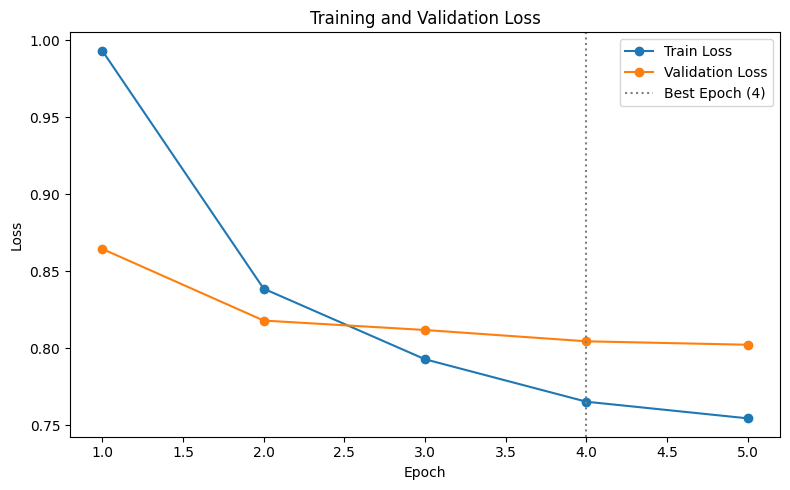

In [17]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


 Classification Report:
              precision    recall  f1-score   support

    positive       0.64      0.64      0.64      1259
    negative       0.67      0.68      0.68      1241
     neutral       0.69      0.67      0.68      1250

    accuracy                           0.66      3750
   macro avg       0.66      0.66      0.66      3750
weighted avg       0.66      0.66      0.66      3750

Confusion Matrix:


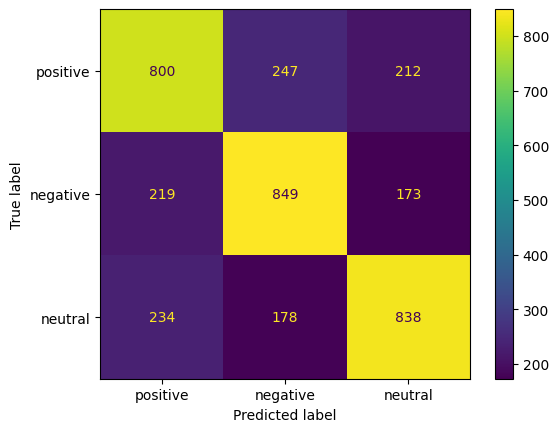

In [18]:
model_finetune.load_state_dict(torch.load(best_ckpt_path, map_location=device))
model_finetune.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader = DataLoader(Dataset(test_tokenized, y_test_tensor), batch_size=batch_size)

model_finetune.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model_finetune(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Report completo
label_names = ['positive', 'negative', 'neutral']  
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()

# FinBert

In [13]:
# FinBert
from transformers import BertTokenizer, BertForSequenceClassification

finbert_tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

train_tokenized_fb = finbert_tokenizer(X_train.tolist(), padding="max_length", truncation=True, return_tensors="pt")
val_tokenized_fb   = finbert_tokenizer(X_val.tolist(),   padding="max_length", truncation=True, return_tensors="pt")
test_tokenized_fb  = finbert_tokenizer(X_test.tolist(),  padding="max_length", truncation=True, return_tensors="pt")

In [14]:
finbert = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Congela tutti i parametri
for param in finbert.parameters():
    param.requires_grad = False

# Scongela solo il classification head
for param in finbert.classifier.parameters():
    param.requires_grad = True

print(finbert.config.id2label)  # <-- guarda l'output di questa riga

finbert.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 59470.59it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'positive', 1: 'negative', 2: 'neutral'}


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [15]:
batch_size   = 32
lr           = 2e-4   # più alto perché alleniamo solo il classifier head
warmup_ratio = 0.1

train_losses_fb = []
val_losses_fb   = []

train_loader_fb = DataLoader(Dataset(train_tokenized_fb, y_train_tensor), batch_size=batch_size)
val_loader_fb   = DataLoader(Dataset(val_tokenized_fb,   y_val_tensor),   batch_size=batch_size)

optimizer_fb = AdamW(filter(lambda p: p.requires_grad, finbert.parameters()), lr=lr, weight_decay=0.01)
epochs       = 5
total_steps  = len(train_loader_fb) * epochs
scheduler_fb = get_linear_schedule_with_warmup(optimizer_fb, num_warmup_steps=int(warmup_ratio * total_steps), num_training_steps=total_steps)

patience         = 2
min_delta        = 0.01
patience_counter = 0
best_val_loss_fb = float('inf')
best_epoch_fb    = -1
best_ckpt_fb     = os.path.join(checkpoint_dir, "finbert_best_model.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(finbert, train_loader_fb, optimizer_fb, scheduler_fb, device)
    val_loss   = eval_epoch(finbert, val_loader_fb, device)
    train_losses_fb.append(train_loss)
    val_losses_fb.append(val_loss)
    print(f"Epoch {epoch+1} — Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss_fb * (1 - min_delta):
        best_val_loss_fb = val_loss
        best_epoch_fb    = epoch + 1
        patience_counter = 0
        torch.save(finbert.state_dict(), best_ckpt_fb)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping. Best epoch: {best_epoch_fb}, Best val loss: {best_val_loss_fb:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch_fb}, Best val loss: {best_val_loss_fb:.4f}")


 Epoch 1/5


Validation: 100%|██████████| 118/118 [00:57<00:00,  2.04it/s]


Epoch 1 — Train loss: 0.9911, Val loss: 0.9361
New best model saved (val_loss=0.9361)

 Epoch 2/5


Validation: 100%|██████████| 118/118 [00:58<00:00,  2.02it/s]


Epoch 2 — Train loss: 0.9275, Val loss: 0.9174
New best model saved (val_loss=0.9174)

 Epoch 3/5


...

Epoch 3 — Train loss: 0.9159, Val loss: 0.9112
No improvement. Patience: 1/2

 Epoch 4/5


Validation: 100%|██████████| 118/118 [00:59<00:00,  2.00it/s]


Epoch 4 — Train loss: 0.9142, Val loss: 0.9066
New best model saved (val_loss=0.9066)

 Epoch 5/5


Validation: 100%|██████████| 118/118 [00:58<00:00,  2.01it/s]

Epoch 5 — Train loss: 0.9101, Val loss: 0.9054
No improvement. Patience: 1/2

✅ Training complete. Best epoch: 4, Best val loss: 0.9066


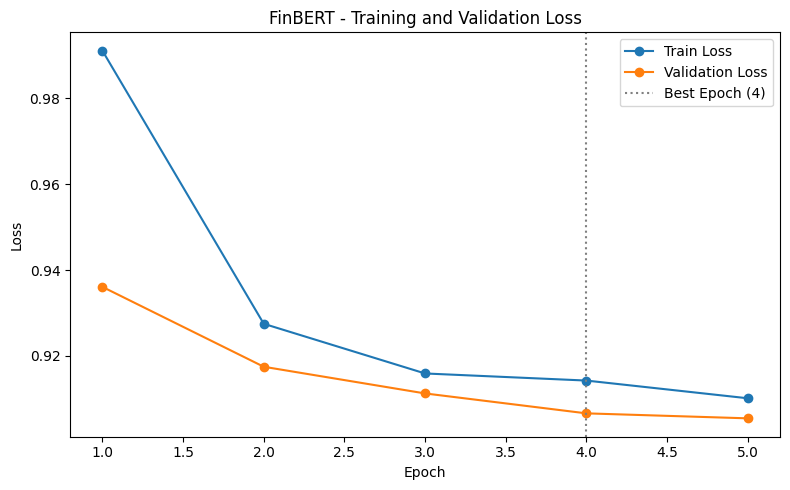

In [16]:
epochs_range = range(1, len(train_losses_fb) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses_fb, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses_fb,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch_fb, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch_fb})')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('FinBERT - Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

    positive       0.60      0.51      0.56      1259
    negative       0.67      0.55      0.60      1241
     neutral       0.53      0.70      0.60      1250

    accuracy                           0.59      3750
   macro avg       0.60      0.59      0.59      3750
weighted avg       0.60      0.59      0.59      3750



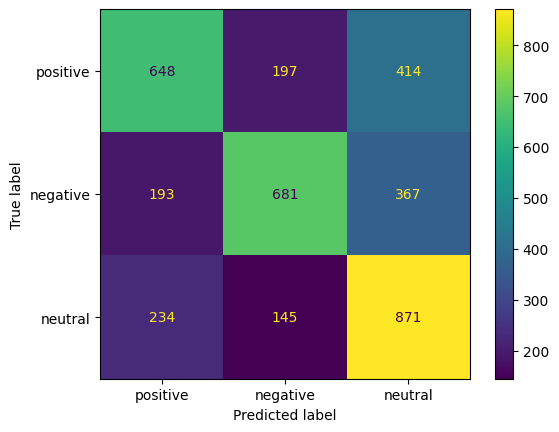

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
test_loader_fb = DataLoader(Dataset(test_tokenized_fb, y_test_tensor), batch_size=batch_size)

finbert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader_fb:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = finbert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print(classification_report(all_labels, all_preds, target_names=label_names))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()